# Product Experimentation with Doubly Robust Estimation: When Both Your Models Are Wrong in LLM Applications

**Keywords:** product experimentation, causal inference, doubly robust estimation, AIPW, augmented inverse-probability weighting, LLM product experiments, noisy observational studies, generative AI

This notebook implements the Augmented Inverse-Probability Weighting (AIPW) estimator from scratch and proves the double-robust property empirically by deliberately misspecifying one model at a time.

**Dataset:** 50,000 synthetic LLM product users. Ground-truth causal effect: +8 percentage points on task completion for agent-mode opt-in.

**Run the dataset generator first:**
```bash
python data/generate_data.py --seed 42 --n-users 50000 \
    --out data/synthetic_llm_logs.csv
```

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

df = pd.read_csv('../data/synthetic_llm_logs.csv')
T = df['opt_in_agent_mode'].values
Y = df['task_completed'].values

naive_ate = Y[T == 1].mean() - Y[T == 0].mean()
print(f'Naive ATE (unadjusted): {naive_ate:+.4f}')
print(f'N treated: {T.sum()}, N control: {(1-T).sum()}')

Naive ATE (unadjusted): +0.2106
N treated: 13451, N control: 36549


## Step 1: Fit the propensity model

In [2]:
X_raw = pd.get_dummies(
    df[['engagement_tier', 'query_confidence']],
    drop_first=True
).astype(float)
X = X_raw.values

ps_model = LogisticRegression(max_iter=1000, C=1.0)
ps_model.fit(X, T)
e_hat = ps_model.predict_proba(X)[:, 1]
e_hat = np.clip(e_hat, 0.01, 0.99)

print(f'Propensity range: {e_hat.min():.3f} to {e_hat.max():.3f}')
print(f'Mean propensity (treated): {e_hat[T == 1].mean():.3f}')
print(f'Mean propensity (control): {e_hat[T == 0].mean():.3f}')

Propensity range: 0.114 to 0.675
Mean propensity (treated): 0.401
Mean propensity (control): 0.220


## Step 2: Fit the outcome models

In [3]:
m1_model = LinearRegression()
m1_model.fit(X[T == 1], Y[T == 1])

m0_model = LinearRegression()
m0_model.fit(X[T == 0], Y[T == 0])

m1_hat = m1_model.predict(X)
m0_hat = m0_model.predict(X)

ate_regression = (m1_hat - m0_hat).mean()
print(f'Regression adjustment ATE: {ate_regression:+.4f}')

Regression adjustment ATE: +0.0847


## Step 3: Combine into the AIPW estimator

In [4]:
def aipw_ate(Y, T, e_hat, m1_hat, m0_hat):
    ipw_treated = T * (Y - m1_hat) / e_hat
    ipw_control = (1 - T) * (Y - m0_hat) / (1 - e_hat)
    phi = m1_hat - m0_hat + ipw_treated - ipw_control
    return phi.mean(), phi

ate_aipw, phi_obs = aipw_ate(Y, T, e_hat, m1_hat, m0_hat)
print(f'AIPW ATE:            {ate_aipw:+.4f}')
print(f'Naive ATE:           {naive_ate:+.4f}')
print(f'Regression-only ATE: {ate_regression:+.4f}')
print(f'Ground truth:        +0.0800')

AIPW ATE:            +0.0847
Naive ATE:           +0.2106
Regression-only ATE: +0.0847
Ground truth:        +0.0800


## Step 4: Bootstrap confidence intervals

In [5]:
def aipw_bootstrap(df, X_cols, treatment_col, outcome_col,
                   n_bootstrap=500, seed=7):
    rng = np.random.default_rng(seed)
    n = len(df)
    X_all = pd.get_dummies(df[X_cols], drop_first=True).astype(float).values
    T_all = df[treatment_col].values
    Y_all = df[outcome_col].values
    boot_estimates = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        X_b, T_b, Y_b = X_all[idx], T_all[idx], Y_all[idx]
        ps = LogisticRegression(max_iter=1000, C=1.0)
        ps.fit(X_b, T_b)
        e_b = np.clip(ps.predict_proba(X_b)[:, 1], 0.01, 0.99)
        m1 = LinearRegression().fit(X_b[T_b == 1], Y_b[T_b == 1])
        m0 = LinearRegression().fit(X_b[T_b == 0], Y_b[T_b == 0])
        ate_b, _ = aipw_ate(Y_b, T_b, e_b, m1.predict(X_b), m0.predict(X_b))
        boot_estimates.append(ate_b)
    boot_arr = np.array(boot_estimates)
    return boot_arr, np.percentile(boot_arr, 2.5), np.percentile(boot_arr, 97.5)

boot_dist, ci_lo, ci_hi = aipw_bootstrap(
    df,
    X_cols=['engagement_tier', 'query_confidence'],
    treatment_col='opt_in_agent_mode',
    outcome_col='task_completed',
    n_bootstrap=500,
    seed=7,
)
print(f'AIPW ATE:           {ate_aipw:+.4f}')
print(f'95% Bootstrap CI:   [{ci_lo:+.4f}, {ci_hi:+.4f}]')
print(f'Bootstrap std dev:  {boot_dist.std():.4f}')

AIPW ATE:           +0.0847
95% Bootstrap CI:   [+0.0744, +0.0952]
Bootstrap std dev:  0.0053


## Step 5: Prove the double-robust property via deliberate misspecification

In [6]:
# Scenario 1: constant propensity (e = 0.3 for everyone)
e_wrong = np.full(len(df), 0.3)
t_mask = T == 1
c_mask = T == 0

ate_ipw_wrong = (
    (Y[t_mask] / e_wrong[t_mask]).sum() / (1 / e_wrong[t_mask]).sum()
    - (Y[c_mask] / (1 - e_wrong[c_mask])).sum()
    / (1 / (1 - e_wrong[c_mask])).sum()
)
ate_aipw_wrong_ps, _ = aipw_ate(Y, T, e_wrong, m1_hat, m0_hat)

print('--- Scenario 1: constant propensity (e = 0.3) ---')
print(f'IPW with wrong propensity:         {ate_ipw_wrong:+.4f}  (should be wrong)')
print(f'Regression adjustment (unchanged): {ate_regression:+.4f}  (should be ~0.085)')
print(f'AIPW with wrong propensity:        {ate_aipw_wrong_ps:+.4f}  (should stay ~0.085)')
print(f'Ground truth:                      +0.0800')

--- Scenario 1: constant propensity (e = 0.3) ---
IPW with wrong propensity:         +0.2106  (should be wrong)
Regression adjustment (unchanged): +0.0847  (should be ~0.085)
AIPW with wrong propensity:        +0.0847  (should stay ~0.085)
Ground truth:                      +0.0800


In [7]:
# Scenario 2: constant outcome models (m1 = m0 = 0.5 for everyone)
m1_wrong = np.full(len(df), 0.5)
m0_wrong = np.full(len(df), 0.5)

ate_regression_wrong = (m1_wrong - m0_wrong).mean()
ate_ipw_correct = (
    (Y[t_mask] / e_hat[t_mask]).sum() / (1 / e_hat[t_mask]).sum()
    - (Y[c_mask] / (1 - e_hat[c_mask])).sum()
    / (1 / (1 - e_hat[c_mask])).sum()
)
ate_aipw_wrong_out, _ = aipw_ate(Y, T, e_hat, m1_wrong, m0_wrong)

print('--- Scenario 2: constant outcome models (m1 = m0 = 0.5) ---')
print(f'Regression with wrong outcome models: {ate_regression_wrong:+.4f}  (should be 0.0)')
print(f'IPW with correct propensity:          {ate_ipw_correct:+.4f}  (should be ~0.085)')
print(f'AIPW with wrong outcome models:       {ate_aipw_wrong_out:+.4f}  (should stay ~0.085)')
print(f'Ground truth:                         +0.0800')

--- Scenario 2: constant outcome models (m1 = m0 = 0.5) ---
Regression with wrong outcome models: +0.0000  (should be 0.0)
IPW with correct propensity:          +0.0851  (should be ~0.085)
AIPW with wrong outcome models:       +0.0849  (should stay ~0.085)
Ground truth:                         +0.0800


## Propensity score overlap (Figure 2)

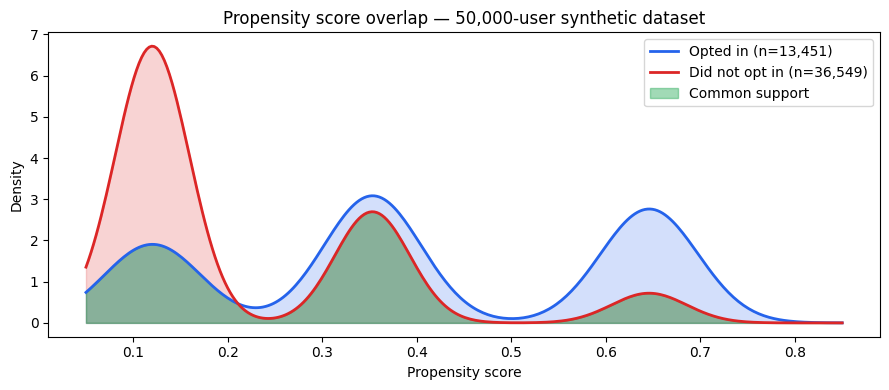

In [8]:
from scipy.stats import gaussian_kde

ps_treated = e_hat[T == 1]
ps_control = e_hat[T == 0]
x_grid = np.linspace(0.05, 0.85, 300)
kde_t = gaussian_kde(ps_treated, bw_method=0.25)(x_grid)
kde_c = gaussian_kde(ps_control, bw_method=0.25)(x_grid)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(x_grid, kde_t, alpha=0.2, color='#2563EB')
ax.fill_between(x_grid, kde_c, alpha=0.2, color='#DC2626')
ax.plot(x_grid, kde_t, color='#2563EB', lw=2, label=f'Opted in (n={T.sum():,})')
ax.plot(x_grid, kde_c, color='#DC2626', lw=2, label=f'Did not opt in (n={(1-T).sum():,})')
ax.fill_between(x_grid, np.minimum(kde_t, kde_c), alpha=0.4,
                color='#16A34A', label='Common support')
ax.set_xlabel('Propensity score')
ax.set_ylabel('Density')
ax.set_title('Propensity score overlap — 50,000-user synthetic dataset')
ax.legend()
plt.tight_layout()
plt.show()

## Results summary

| Estimator | ATE estimate | Notes |
|-----------|-------------|-------|
| Naive (unadjusted) | +0.2106 | Heavily inflated by selection bias |
| Regression adjustment | +0.0847 | Outcome model only |
| AIPW | +0.0847 | Doubly robust |
| **95% Bootstrap CI** | **[+0.0744, +0.0952]** | 500 replicates, seed=7 |
| Ground truth | +0.0800 | Baked into data generator |

**Double-robust property verified:**
- Scenario 1 (wrong propensity, correct outcome): AIPW stays at +0.0847 ✓
- Scenario 2 (correct propensity, wrong outcome): AIPW stays at +0.0849 ✓